  NGC4698: 283391 HII pixels


/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_42088/1620638054.py:171: RuntimeWarning: divide by zero encountered in divide
  logN2_hii = np.log10(NII_common_HII / HA_common_HII)
/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_42088/1620638054.py:173: RuntimeWarning: divide by zero encountered in divide
  logO3_hii = np.log10(OIII_common_HII / HB_common_HII)
/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_42088/1620638054.py:173: RuntimeWarning: divide by zero encountered in log10
  logO3_hii = np.log10(OIII_common_HII / HB_common_HII)
/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_42088/1620638054.py:175: RuntimeWarning: divide by zero encountered in divide
  logS2_hii = np.log10((SII6716_common_HII + SII6730_common_HII) / HA_common_HII)
/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_42088/1620638054.py:175: RuntimeWarning: divide by zero encountered in log10
  logS2_hii = np.log10((SII6716_common_HII + SII6730_common_HII) / H


Total combined HII pixels: 283391

=== Combined BPT Diagram Summary (HII only) ===
  N2 BPT - Total HII: 154289 (54.4%)
  S2 BPT - Total HII: 80659 (28.5%)

Galaxy breakdown for HII spaxels:
  NGC4698: N2_HII=154289, S2_HII=80659

Successfully created combined BPT diagrams (HII only) colored by galaxy from 1 galaxies
Galaxies included: NGC4698


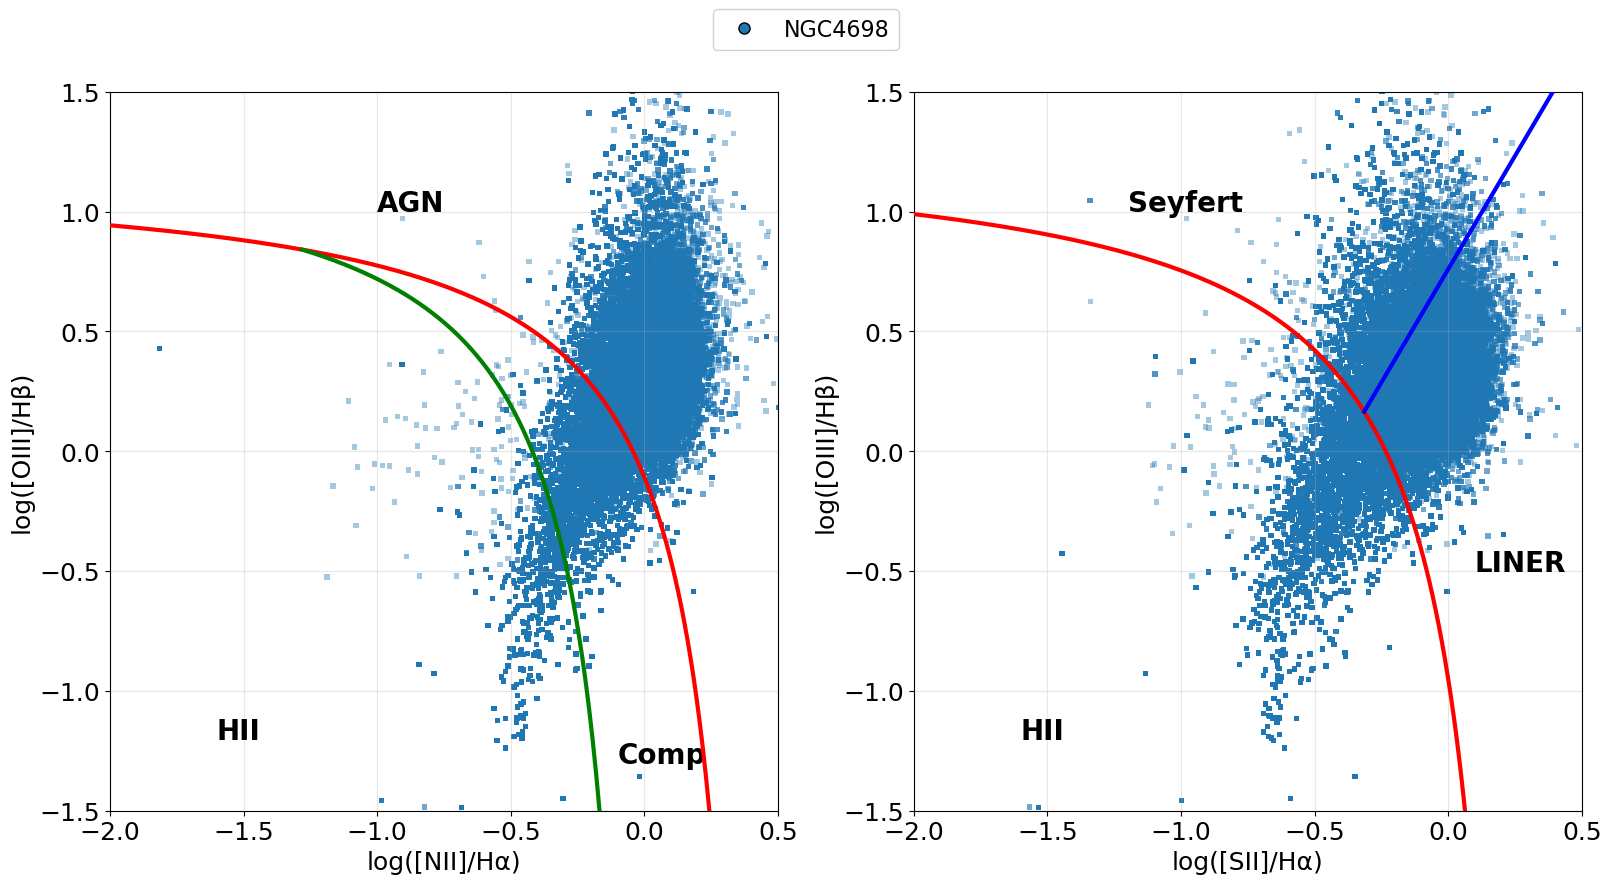

In [3]:
# ------------------------------------------------------------------

# Combined Analysis: NII and SII BPT Diagrams - Color-coded by Galaxy

# Collect all HII spaxels from all galaxies (HII only, no SF)

# Uses common spaxels across all 4 metallicity calibrations

# ------------------------------------------------------------------

import numpy as np

import matplotlib.pyplot as plt

from matplotlib.lines import Line2D

from pathlib import Path

from astropy.io import fits



# BPT reference line functions

def kewley01_N2(x):   # max-starburst

    return 0.61/(x-0.47) + 1.19



def kauff03_N2(x):    # empirical SF upper envelope

    return 0.61/(x-0.05) + 1.30



def kewley01_S2(x):

    return 0.72/(x-0.32) + 1.30



def kewley06_Sy_LIN(x):   # Seyfert/LINER division

    return 1.89*x + 0.76



# Create x arrays for the theoretical lines

x_kewley_N2 = np.linspace(-2.0, 0.3, 200)

x_kauff_N2 = np.linspace((286-np.sqrt(2871561))/1100, 0.0, 200)

x_kewley_S2 = np.linspace(-2.0, 0.3, 200)

x_kewley06_S2 = np.linspace((159-np.sqrt(105081))/525, 0.5, 200)



# Get all galaxies from binning files

bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))

galaxies = [f.name.split('_')[0] for f in bins]
galaxies = ['NGC4698']


# Create galaxy color mapping (consistent for all HII regions)

galaxy_colors = plt.cm.tab20(np.linspace(0, 1, len(galaxies)))

galaxy_color_dict = dict(zip(galaxies, galaxy_colors))



# Collect all spaxels from all galaxies - HII only (with galaxy indices)

all_logN2_hii = []

all_logO3_hii = []

all_logS2_hii = []

all_galaxy_indices_hii = []



print("Collecting HII data from all galaxies...")

for gal_idx, gal in enumerate(galaxies):

    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')



    if gas_file.exists() and bin_file.exists():

        # Load maps for this galaxy

        with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:

            logSigmaM = h['LOGMASS_SURFACE_DENSITY'].data

        with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:

            # HII quantities

            logSigmaSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data

            oh_d16_HII = h['O_H_D16_HII'].data

            oh_pg16_HII = h['O_H_PG16_HII'].data

            oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data

            oh_o3n2_c20_HII = h['O_H_O3N2_C20_HII'].data



            # Load corrected emission line fluxes

            HB4861_FLUX_corr = h['HB4861_FLUX_corr'].data

            HA6562_FLUX_corr = h['HA6562_FLUX_corr'].data

            OIII5006_FLUX_corr = h['OIII5006_FLUX_corr'].data

            NII6583_FLUX_corr = h['NII6583_FLUX_corr'].data

            SII6716_FLUX_corr = h['SII6716_FLUX_corr'].data

            SII6730_FLUX_corr = h['SII6730_FLUX_corr'].data



        # Find common spaxels for HII

        common_mask_HII = (np.isfinite(HB4861_FLUX_corr) & np.isfinite(HA6562_FLUX_corr) &
                           np.isfinite(OIII5006_FLUX_corr) & np.isfinite(NII6583_FLUX_corr) &
                           np.isfinite(SII6716_FLUX_corr) & np.isfinite(SII6730_FLUX_corr))



        n_pixels_HII = np.sum(common_mask_HII)

        print(f"  {gal}: {n_pixels_HII} HII pixels")



        # Apply common_mask to get valid spaxels - HII

        HB_common_HII = HB4861_FLUX_corr[common_mask_HII]

        HA_common_HII = HA6562_FLUX_corr[common_mask_HII]

        OIII_common_HII = OIII5006_FLUX_corr[common_mask_HII]

        NII_common_HII = NII6583_FLUX_corr[common_mask_HII]

        SII6716_common_HII = SII6716_FLUX_corr[common_mask_HII]

        SII6730_common_HII = SII6730_FLUX_corr[common_mask_HII]



        # Calculate line ratios - HII

        logN2_hii = np.log10(NII_common_HII / HA_common_HII)

        logO3_hii = np.log10(OIII_common_HII / HB_common_HII)

        logS2_hii = np.log10((SII6716_common_HII + SII6730_common_HII) / HA_common_HII)



        # Append to combined arrays - HII only

        all_logN2_hii.extend(logN2_hii.flatten())

        all_logO3_hii.extend(logO3_hii.flatten())

        all_logS2_hii.extend(logS2_hii.flatten())

        all_galaxy_indices_hii.extend([gal_idx] * len(logN2_hii.flatten()))

    else:

        print(f"  {gal}: Data files not found")



# Convert to numpy arrays - HII

all_logN2_hii = np.array(all_logN2_hii)

all_logO3_hii = np.array(all_logO3_hii)

all_logS2_hii = np.array(all_logS2_hii)

all_galaxy_indices_hii = np.array(all_galaxy_indices_hii)



print(f"\nTotal combined HII pixels: {len(all_logN2_hii)}")



# Apply BPT classifications - HII only

mask_N2_HII = all_logO3_hii <= kauff03_N2(all_logN2_hii)

mask_N2_Comp = (all_logO3_hii > kauff03_N2(all_logN2_hii)) & (all_logO3_hii <= kewley01_N2(all_logN2_hii))

mask_N2_AGN = all_logO3_hii > kewley01_N2(all_logN2_hii)



mask_S2_HII = all_logO3_hii <= kewley01_S2(all_logS2_hii)

mask_S2_above_kewley = all_logO3_hii > kewley01_S2(all_logS2_hii)

mask_S2_LINER = mask_S2_above_kewley & (all_logO3_hii <= kewley06_Sy_LIN(all_logS2_hii))

mask_S2_Seyfert = mask_S2_above_kewley & (all_logO3_hii > kewley06_Sy_LIN(all_logS2_hii))



mask_HII_N2 = mask_N2_HII | mask_N2_Comp

mask_HII_S2 = mask_S2_HII



# Create BPT diagrams: HII only (single row, two panels)

# Use constrained_layout for better spacing with legend

fig, axes = plt.subplots(1, 2, figsize=(16, 8), constrained_layout=True)



# ===== HII REGIONS ONLY =====



# NII BPT Diagram - HII

ax = axes[0]



for gal_idx, gal in enumerate(galaxies):

    gal_mask = (all_galaxy_indices_hii == gal_idx)
    if np.sum(gal_mask) > 0:

        ax.scatter(all_logN2_hii[gal_mask], all_logO3_hii[gal_mask], 

                   color=galaxy_colors[gal_idx], marker=',', s=15, alpha=0.4, 

                   edgecolors='none', rasterized=True)



ax.plot(x_kewley_N2, kewley01_N2(x_kewley_N2), 'r-', lw=3, label='Kewley+01', zorder=10)

ax.plot(x_kauff_N2, kauff03_N2(x_kauff_N2), 'g-', lw=3, label='Kauffmann+03', zorder=10)



hii_count_N2 = np.sum(mask_HII_N2)

total_common_hii = len(all_logN2_hii)

hii_percent_N2 = hii_count_N2 / total_common_hii * 100 if total_common_hii > 0 else 0



ax.set_xlabel('log([NII]/Hα)', fontsize=18)

ax.set_ylabel('log([OIII]/Hβ)', fontsize=18)

ax.tick_params(axis='both', which='major', labelsize=18)

ax.set_xlim(-2.0, 0.5)

ax.set_ylim(-1.5, 1.5)

# ax.set_title('NII BPT (Common HII spaxels by Galaxy)', fontsize=14)

ax.text(-1.6, -1.2, 'HII', fontsize=20, fontweight='bold')

ax.text(-0.1, -1.3, 'Comp', fontsize=20, fontweight='bold')

ax.text(-1.0, 1.0, 'AGN', fontsize=20, fontweight='bold')

ax.grid(True, alpha=0.3)



# SII BPT Diagram - HII

ax = axes[1]



for gal_idx, gal in enumerate(galaxies):

    gal_mask = (all_galaxy_indices_hii == gal_idx)
    if np.sum(gal_mask) > 0:

        ax.scatter(all_logS2_hii[gal_mask], all_logO3_hii[gal_mask], 

                   color=galaxy_colors[gal_idx], marker=',', s=15, alpha=0.4, 

                   edgecolors='none', rasterized=True)



ax.plot(x_kewley_S2, kewley01_S2(x_kewley_S2), 'r-', lw=3, label='Kewley+01', zorder=10)

ax.plot(x_kewley06_S2, kewley06_Sy_LIN(x_kewley06_S2), 'b-', lw=3, label='Kewley+06', zorder=10)



hii_count_S2 = np.sum(mask_HII_S2)

hii_percent_S2 = hii_count_S2 / total_common_hii * 100 if total_common_hii > 0 else 0



ax.set_xlabel('log([SII]/Hα)', fontsize=18)

ax.set_ylabel('log([OIII]/Hβ)', fontsize=18)

ax.tick_params(axis='both', which='major', labelsize=18)

ax.set_xlim(-2.0, 0.5)

ax.set_ylim(-1.5, 1.5)

# ax.set_title('SII BPT (Common HII spaxels by Galaxy)', fontsize=14)

ax.text(-1.6, -1.2, 'HII', fontsize=20, fontweight='bold')

ax.text(-1.2, 1.0, 'Seyfert', fontsize=20, fontweight='bold')

ax.text(0.1, -0.5, 'LINER', fontsize=20, fontweight='bold')

ax.grid(True, alpha=0.3)



# Build custom legend handles with larger markers

legend_handles = []

legend_labels = []

for gal_idx, gal in enumerate(galaxies):

    legend_handles.append(Line2D([0], [0], marker='o', color='none', 

                                 markerfacecolor=galaxy_colors[gal_idx], markersize=8, linestyle='None'))

    legend_labels.append(f'{gal}')



# Put legend above the axes at 1.1 (outside plot)

fig.legend(legend_handles, legend_labels, loc='upper center',

           bbox_to_anchor=(0.5, 1.1),

           ncol=min(len(legend_labels), 7), fontsize=16, framealpha=0.9)



# Save PNG tightly cropped, PDF with standard bbox (no cropping of legend)

# fig.savefig('Plot_Paper_1/Combined_BPT_diagrams_by_Galaxy_HII.png', dpi=600, bbox_inches='tight', pad_inches=0.05)

# fig.savefig('Plot_Paper_1/Combined_BPT_diagrams_by_Galaxy_HII.pdf', dpi=600, bbox_inches='tight', pad_inches=0.05)



# Print summary statistics (HII only)

print(f"\n=== Combined BPT Diagram Summary (HII only) ===")

print(f"  N2 BPT - Total HII: {hii_count_N2} ({hii_percent_N2:.1f}%)")

print(f"  S2 BPT - Total HII: {hii_count_S2} ({hii_percent_S2:.1f}%)")



# Print galaxy breakdown for HII spaxels

print(f"\nGalaxy breakdown for HII spaxels:")

for gal_idx, gal in enumerate(galaxies):

    gal_n2 = np.sum((all_galaxy_indices_hii == gal_idx) & mask_HII_N2)

    gal_s2 = np.sum((all_galaxy_indices_hii == gal_idx) & mask_HII_S2)

    print(f"  {gal}: N2_HII={gal_n2}, S2_HII={gal_s2}")



print(f"\nSuccessfully created combined BPT diagrams (HII only) colored by galaxy from {len(galaxies)} galaxies")

print(f"Galaxies included: {', '.join(galaxies)}")